In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import pickle

In [22]:
dataset = pd.read_csv("Mall_Customers.csv")

In [23]:
X = dataset.iloc[:, [2, 3, 4]].values

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

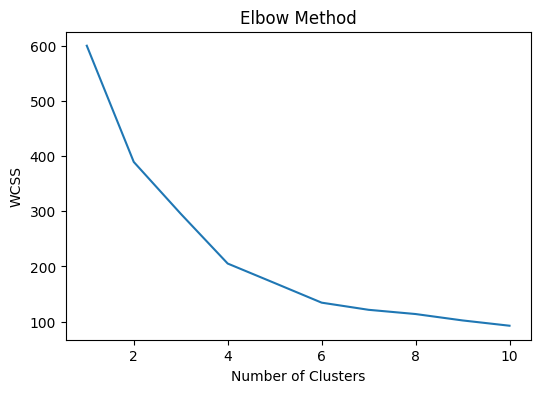

In [25]:
wcss = []
for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


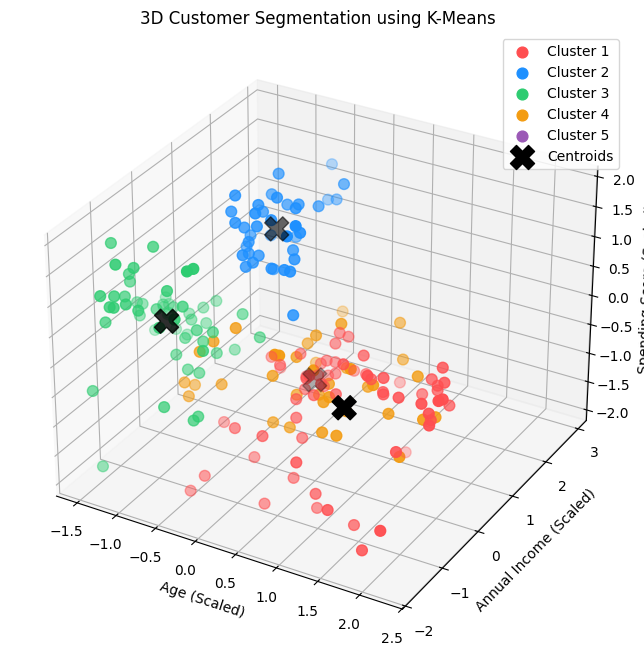

In [36]:
colors = ['#FF4E50', '#1E90FF', '#2ECC71', '#F39C12', '#9B59B6']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster
for i in range(5):
    ax.scatter(
        X_scaled[y_kmeans == i, 0],   # Age
        X_scaled[y_kmeans == i, 1],   # Income
        X_scaled[y_kmeans == i, 2],   # Spending Score
        s=60,
        c=colors[i],
        label=f'Cluster {i+1}'
    )

# Plot Centroids
ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

# Labels
ax.set_xlabel('Age (Scaled)')
ax.set_ylabel('Annual Income (Scaled)')
ax.set_zlabel('Spending Score (Scaled)')
ax.set_title('3D Customer Segmentation using K-Means')

ax.legend()
plt.show()

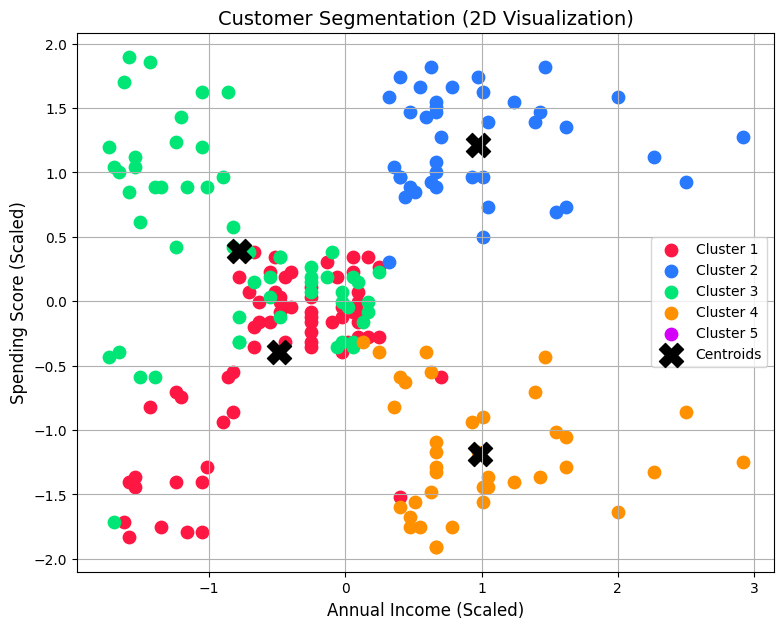

In [38]:
# ===============================
# 2D CUSTOMER SEGMENTATION PLOT
# ===============================

import matplotlib.pyplot as plt

# Attractive color palette
colors = ['#FF1744',  # Bright Red
          '#2979FF',  # Bright Blue
          '#00E676',  # Neon Green
          '#FF9100',  # Bright Orange
          '#D500F9']  # Bright Purple
plt.figure(figsize=(9,7))

# Plot each cluster
for i in range(5):
    plt.scatter(
        X_scaled[y_kmeans == i, 1],   # Annual Income
        X_scaled[y_kmeans == i, 2],   # Spending Score
        s=80,
        c=colors[i],
        label=f'Cluster {i+1}'
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation (2D Visualization)', fontsize=14)
plt.xlabel('Annual Income (Scaled)', fontsize=12)
plt.ylabel('Spending Score (Scaled)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [39]:
with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
